# Titanic Survival Prediction

**CODSOFT Data Science Internship — Task 1**

Predicting whether a Titanic passenger survived using passenger attributes (class, sex, age, fare, family size, etc.). This notebook covers data loading, cleaning, EDA, feature engineering, and comparison of three classification models.

Dataset: [Titanic Dataset (Kaggle)](https://www.kaggle.com/datasets/yasserh/titanic-dataset)


## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Dataset

In [10]:
df = pd.read_csv('titanic.csv')
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3. Exploratory Data Analysis

Let's look at how survival relates to passenger class, sex, age, embarkation port, and fare.

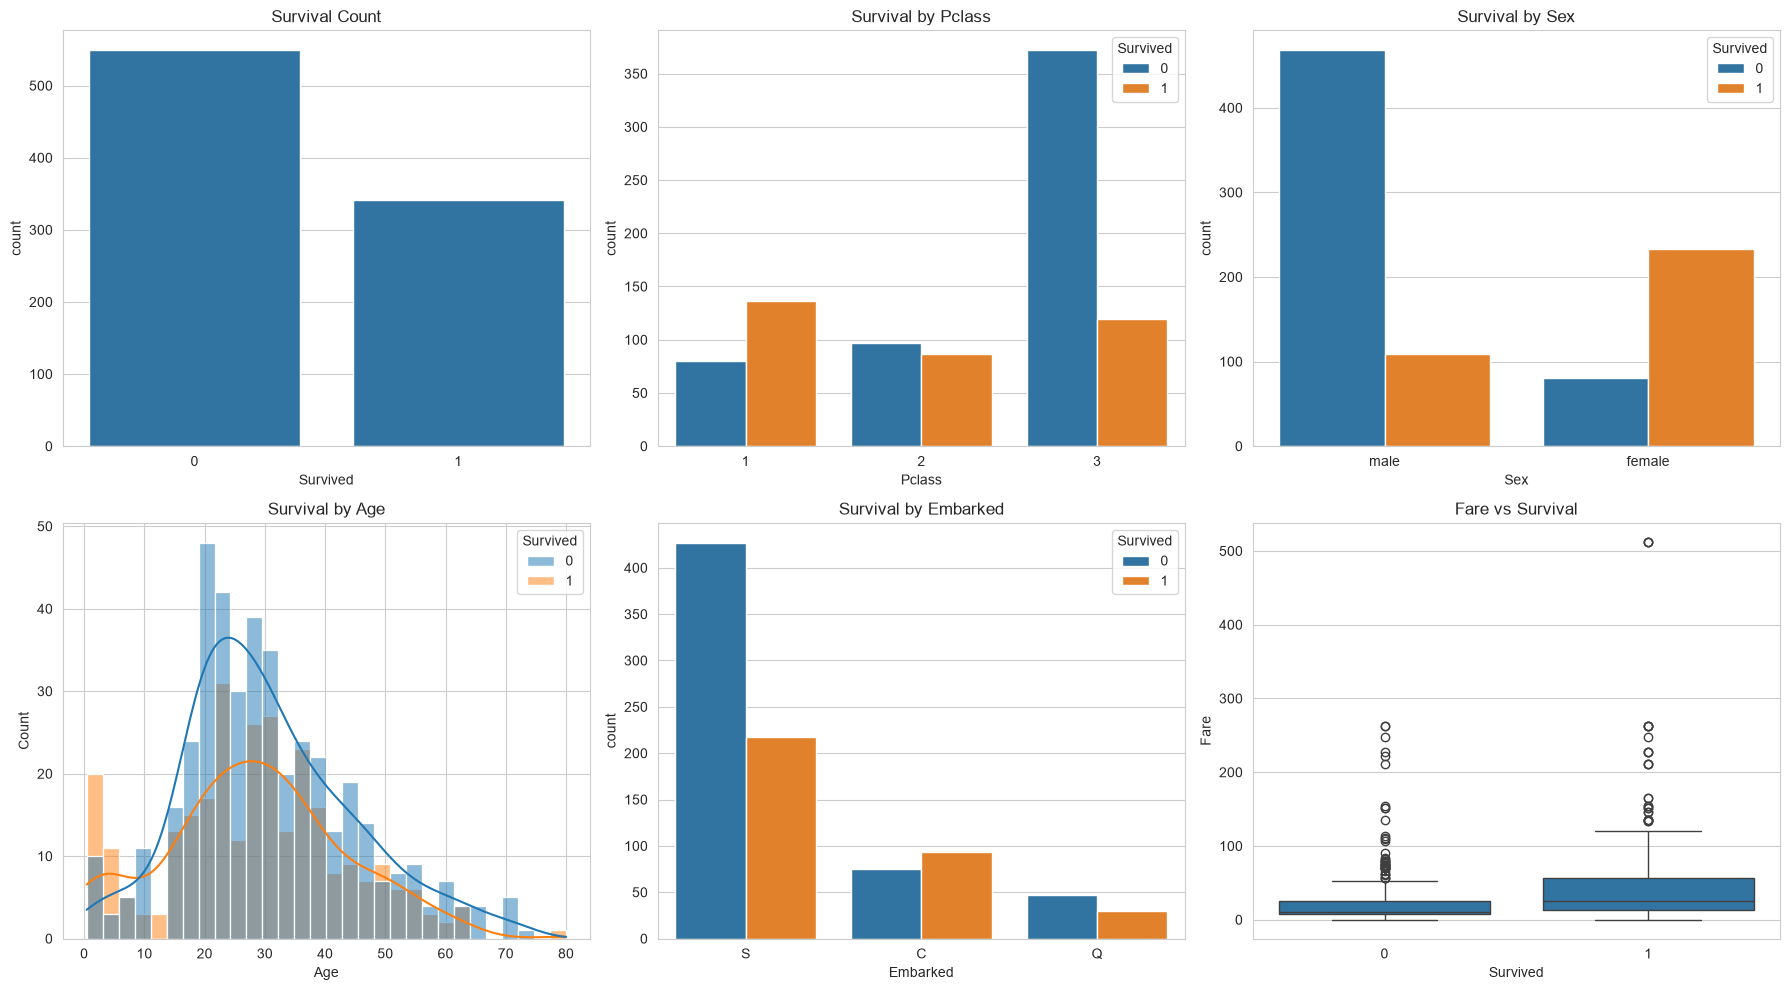

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(x='Survived', data=df, ax=axes[0,0]).set_title('Survival Count')
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0,1]).set_title('Survival by Pclass')
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0,2]).set_title('Survival by Sex')
sns.histplot(data=df, x='Age', hue='Survived', kde=True, ax=axes[1,0], bins=30).set_title('Survival by Age')
sns.countplot(x='Embarked', hue='Survived', data=df, ax=axes[1,1]).set_title('Survival by Embarked')
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1,2]).set_title('Fare vs Survival')

plt.tight_layout()
plt.show()

**Key observations:**
- Women had a much higher survival rate than men.
- 1st class passengers survived at a higher rate than 3rd class.
- Passengers who paid higher fares were more likely to survive (correlated with class).
- Passengers embarking from Cherbourg (C) had a slightly higher survival rate.

## 4. Feature Engineering

- Extract **Title** from the passenger's Name (Mr, Mrs, Miss, Master, Rare)
- Create **FamilySize** and **IsAlone** from SibSp + Parch
- Create **HasCabin** flag (most Cabin values are missing, but presence itself is informative)
- Impute missing **Age** using median age per Title group
- Bin Age and Fare into categories

In [14]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')

title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
    'Capt': 'Rare', 'Sir': 'Rare'
}
df['Title'] = df['Title'].map(title_map).fillna('Rare')

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['HasCabin'] = df['Cabin'].notna().astype(int)

df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, 100],
                       labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior'])
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Mid', 'High', 'VeryHigh'])

df[['Title', 'FamilySize', 'IsAlone', 'HasCabin', 'AgeBin', 'FareBin']].head()

,Title,FamilySize,IsAlone,HasCabin,AgeBin,FareBin
0,Mr,2,0,0,Adult,Low
1,Mrs,2,0,1,Adult,VeryHigh
2,Miss,1,1,0,Adult,Mid
3,Mrs,2,0,1,Adult,VeryHigh
4,Mr,1,1,0,Adult,Mid


## 5. Encode Categorical Features

In [15]:
le = LabelEncoder()
for col in ['Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin']:
    df[col] = le.fit_transform(df[col].astype(str))

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
            'Title', 'FamilySize', 'IsAlone', 'HasCabin', 'AgeBin', 'FareBin']

X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (712, 13) Test shape: (179, 13)


## 6. Train & Compare Models

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    cv_scores = cross_val_score(model, X, y, cv=5)
    results[name] = {'test_acc': acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f"\n{name}: Test Acc={acc:.4f}, CV Mean={cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(classification_report(y_test, preds))


Logistic Regression: Test Acc=0.8156, CV Mean=0.8025 (+/- 0.0119)
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179


Decision Tree: Test Acc=0.7486, CV Mean=0.8024 (+/- 0.0318)
              precision    recall  f1-score   support

           0       0.75      0.89      0.81       110
           1       0.75      0.52      0.62        69

    accuracy                           0.75       179
   macro avg       0.75      0.71      0.71       179
weighted avg       0.75      0.75      0.74       179


Random Forest: Test Acc=0.8324, CV Mean=0.8249 (+/- 0.0161)
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77     

## 7. Best Model — Confusion Matrix & Feature Importance

Best model: Random Forest


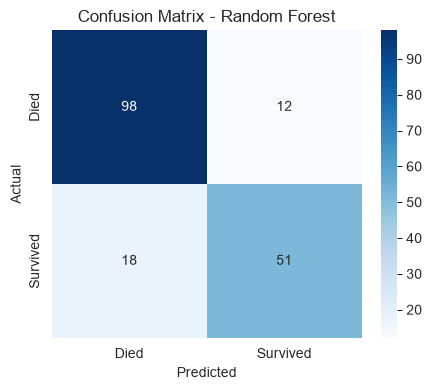

In [17]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_model = models[best_name]
print("Best model:", best_name)

preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

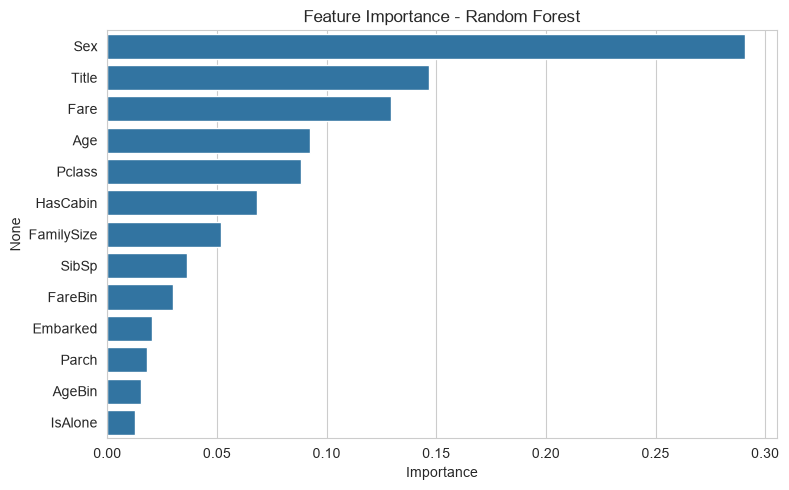

Sex           0.290722
Title         0.146621
Fare          0.129482
Age           0.092406
Pclass        0.088336
HasCabin      0.068071
FamilySize    0.051774
SibSp         0.036172
FareBin       0.029956
Embarked      0.020406
Parch         0.017872
AgeBin        0.015473
IsAlone       0.012705
dtype: float64

In [18]:
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f'Feature Importance - {best_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

## 8. Summary

| Model | Test Accuracy | CV Mean Accuracy |
|---|---|---|
| Logistic Regression | ~81.6% | ~80.2% |
| Decision Tree | ~74.9% | ~80.2% |
| **Random Forest** | **~83.2%** | **~82.5%** |

**Conclusion:** Random Forest performed best. `Sex`, `Title`, `Fare`, `Age`, and `Pclass` are the most influential features — consistent with the historical "women and children first" evacuation policy and the survival advantage of wealthier, higher-class passengers.

---
*Task 1 of the CODSOFT Data Science Internship.*

In [19]:
def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked, name="Mr. Unknown"):
    # Extract title from name, same as training
    title = name.split(',')[1].split('.')[0].strip() if ',' in name else 'Mr'
    title_map_lookup = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
        'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
        'Capt': 'Rare', 'Sir': 'Rare'
    }
    title = title_map_lookup.get(title, 'Rare')

    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0
    has_cabin = 0  # unknown for a new passenger, assume no recorded cabin

    # Same encodings LabelEncoder assigned during training (alphabetical order)
    sex_enc = {'female': 0, 'male': 1}[sex]
    embarked_enc = {'C': 0, 'Q': 1, 'S': 2}[embarked]
    title_enc = {'Master': 0, 'Miss': 1, 'Mr': 2, 'Mrs': 3, 'Rare': 4}[title]

    age_bin = pd.cut([age], bins=[0, 12, 20, 40, 60, 100],
                      labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior'])[0]
    age_bin_enc = {'Adult': 0, 'Child': 1, 'MiddleAge': 2, 'Senior': 3, 'Teen': 4}[age_bin]

    if fare <= 7.91:
        fare_bin_enc = {'Low': 1, 'Mid': 2, 'High': 0, 'VeryHigh': 3}['Low']
    elif fare <= 14.45:
        fare_bin_enc = {'Low': 1, 'Mid': 2, 'High': 0, 'VeryHigh': 3}['Mid']
    elif fare <= 31:
        fare_bin_enc = {'Low': 1, 'Mid': 2, 'High': 0, 'VeryHigh': 3}['High']
    else:
        fare_bin_enc = {'Low': 1, 'Mid': 2, 'High': 0, 'VeryHigh': 3}['VeryHigh']

    input_data = pd.DataFrame([{
        'Pclass': pclass, 'Sex': sex_enc, 'Age': age, 'SibSp': sibsp,
        'Parch': parch, 'Fare': fare, 'Embarked': embarked_enc,
        'Title': title_enc, 'FamilySize': family_size, 'IsAlone': is_alone,
        'HasCabin': has_cabin, 'AgeBin': age_bin_enc, 'FareBin': fare_bin_enc
    }])

    prediction = best_model.predict(input_data)[0]
    probability = best_model.predict_proba(input_data)[0][1]
    result = "SURVIVED" if prediction == 1 else "DID NOT SURVIVE"
    print(f"Prediction: {result} (survival probability: {probability:.1%})")
    return prediction

# Try it out — edit these values to test different passengers
predict_survival(pclass=1, sex='female', age=28, sibsp=0, parch=0, fare=100, embarked='S', name="Mrs. Jane Smith")

Prediction: SURVIVED (survival probability: 77.5%)


np.int64(1)